<a href="https://colab.research.google.com/github/Parthingale11/Crime-Data-Analysis/blob/main/Crime_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

       DR_NO        Date Rptd        DATE OCC TIME OCC AREA   AREA NAME  \
0  190326475    3/1/2020 0:00   3/1/2020 0:00     2130    7    Wilshire   
1  200106753    2/9/2020 0:00   2/8/2020 0:00     1800    1     Central   
2  200320258  11/11/2020 0:00  11/4/2020 0:00     1700    3   Southwest   
3  200907217   5/10/2023 0:00  3/10/2020 0:00     2037    9    Van Nuys   
4  200412582    9/9/2020 0:00   9/9/2020 0:00      630    4  Hollenbeck   

  Rpt Dist No Part 1-2 Crm Cd                               Crm Cd Desc  ...  \
0         784        1    510                          VEHICLE - STOLEN  ...   
1         182        1    330                     BURGLARY FROM VEHICLE  ...   
2         356        1    480                             BIKE - STOLEN  ...   
3         964        1    343  SHOPLIFTING-GRAND THEFT ($950.01 & OVER)  ...   
4         413        1    510                          VEHICLE - STOLEN  ...   

  Status   Status Desc Crm Cd 1 Crm Cd 

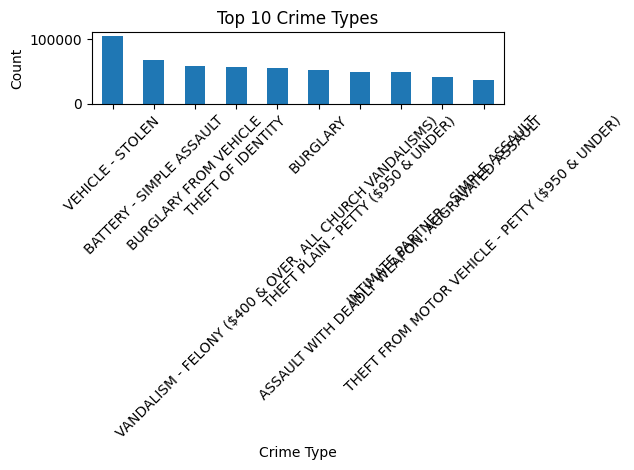

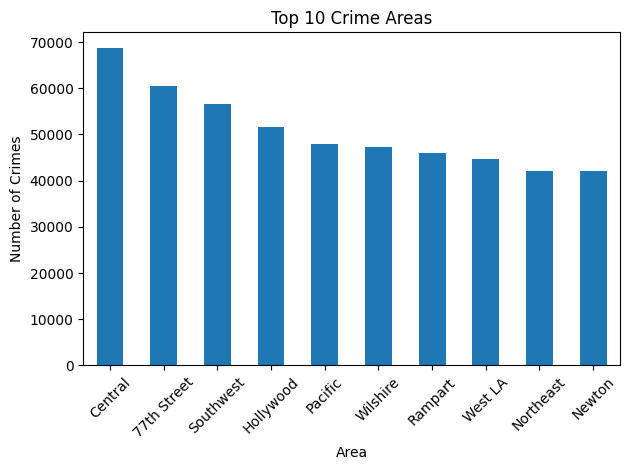

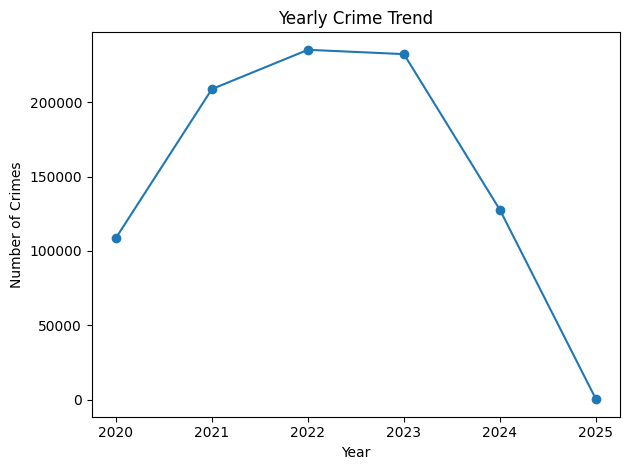

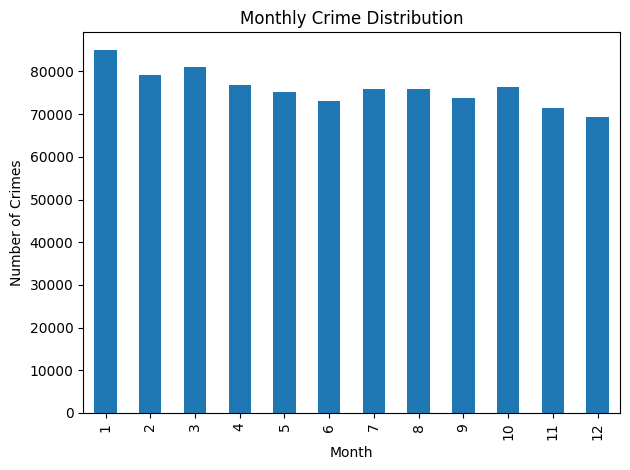

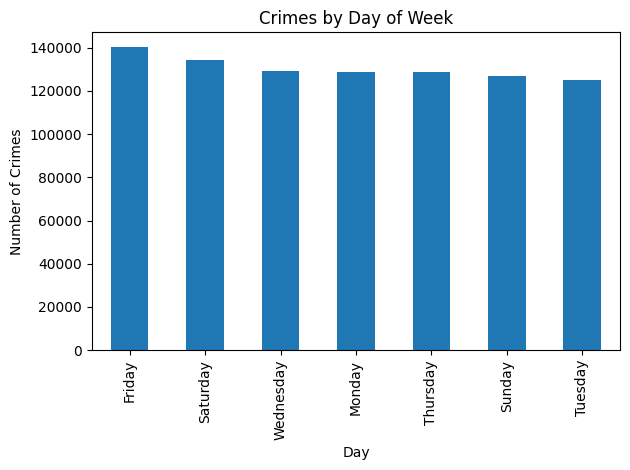


Cross Analysis (Area vs Crime Type):

Crime_Type                                101  34.1794  440  740  ARSON  \
Area                                                                      
            AV                              0        0    0    0      0   
 FEET OR BODILY FORCE)"                     0        0    0    0      0   
-118.2652                                   0        0    0    0      0   
11100    STRATHERN                    ST    0        0    0    0      0   
740                                         0        0    0    0      0   

Crime_Type                                ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER  \
Area                                                                                     
            AV                                                                       0   
 FEET OR BODILY FORCE)"                                                              0   
-118.2652                                                                  

In [7]:
# =========================================
# Crime Data Analysis Project (Final Code)
# =========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Load Dataset
# -----------------------------------------
data = pd.read_csv("/content/sample_data/Crime_Data_from_2020_to_Present.csv", sep=',', engine='python', on_bad_lines='skip')

print("Dataset Loaded Successfully\n")

# Preview Data
print(data.head())

# -----------------------------------------
# 2. Data Cleaning
# -----------------------------------------

# Rename columns for better readability
data.rename(columns={
    'Crm Cd Desc': 'Crime_Type',
    'AREA NAME': 'Area',
    'DATE OCC': 'Date'
}, inplace=True)

# Convert Date column
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Handle missing values
data.ffill(inplace=True)

# Drop duplicates
data.drop_duplicates(inplace=True)

print("\nData Cleaning Completed\n")

# -----------------------------------------
# 3. Feature Engineering
# -----------------------------------------
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.day_name()

print("New Features Added\n")

# -----------------------------------------
# 4. Exploratory Data Analysis
# -----------------------------------------

# 4.1 Crime Type Distribution
crime_type_counts = data['Crime_Type'].value_counts().head(10)

plt.figure()
crime_type_counts.plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------------

# 4.2 Crime by Area
area_counts = data['Area'].value_counts().head(10)

plt.figure()
area_counts.plot(kind='bar')
plt.title("Top 10 Crime Areas")
plt.xlabel("Area")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------------

# 4.3 Yearly Crime Trend
yearly_trend = data['Year'].value_counts().sort_index()

plt.figure()
yearly_trend.plot(kind='line', marker='o')
plt.title("Yearly Crime Trend")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

# -----------------------------------------

# 4.4 Monthly Crime Pattern
monthly_trend = data['Month'].value_counts().sort_index()

plt.figure()
monthly_trend.plot(kind='bar')
plt.title("Monthly Crime Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

# -----------------------------------------

# 4.5 Day-wise Crime Analysis
daywise = data['DayOfWeek'].value_counts()

plt.figure()
daywise.plot(kind='bar')
plt.title("Crimes by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

# -----------------------------------------

# 4.6 Crime Type vs Area (Cross Analysis)
cross_analysis = pd.crosstab(data['Area'], data['Crime_Type'])

print("\nCross Analysis (Area vs Crime Type):\n")
print(cross_analysis.head())

# -----------------------------------------
# 5. Insights
# -----------------------------------------

top_crime = data['Crime_Type'].mode()[0]
top_area = data['Area'].mode()[0]
peak_month = data['Month'].mode()[0]

print("\n==============================")
print("FINAL INSIGHTS")
print("==============================")
print(f"Most Frequent Crime Type: {top_crime}")
print(f"Area with Highest Crime: {top_area}")
print(f"Peak Crime Month: {peak_month}")

# -----------------------------------------
# 6. Conclusion
# -----------------------------------------
print("\nProject Completed Successfully ✅")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
